In [34]:
%%time

train = pd.read_csv('total_df.csv')
train.head()

CPU times: user 153 ms, sys: 0 ns, total: 153 ms
Wall time: 151 ms


,MP,SMILES
0,355.15,O=[N+]([O-])c1c(O)cccc1O
1,373.65,Cc1c([N+](=O)[O-])cc([N+](=O)[O-])c(N(C)[N+](=...
2,373.75,O=c1ccc([N+](=O)[O-])cn1Cc1ccccc1
3,373.70,N#CC(Cc1ccccc1)(Cc1ccco1)c1ccc([N+](=O)[O-])cc1
4,374.25,CCOC(=O)c1cc2ccccc2cc1-c1ccc([N+](=O)[O-])cc1


In [36]:
train = train.dropna()
train

,MP,SMILES
0,355.15,O=[N+]([O-])c1c(O)cccc1O
1,373.65,Cc1c([N+](=O)[O-])cc([N+](=O)[O-])c(N(C)[N+](=...
2,373.75,O=c1ccc([N+](=O)[O-])cn1Cc1ccccc1
3,373.70,N#CC(Cc1ccccc1)(Cc1ccco1)c1ccc([N+](=O)[O-])cc1
4,374.25,CCOC(=O)c1cc2ccccc2cc1-c1ccc([N+](=O)[O-])cc1
...,...,...
98343,411.15,CCCCNC(=O)C(c1cc(OC)cc(OC)c1)N(Cc1ccccc1)C(=O)...
98344,458.15,CCCCNC(=O)C(c1cc2ccccc2c2ccccc12)N(Cc1ccco1)C(...
98345,476.15,CC(C)(C)NC(=O)C(c1ccccc1)N(Cc1ccco1)C(=O)CNC(=...
98346,450.15,COc1ccc(C(C(=O)NCc2ccccc2)N(Cc2ccc(C)o2)C(=O)C...


In [37]:
train = train.reset_index(drop=True)
train

,MP,SMILES
0,355.15,O=[N+]([O-])c1c(O)cccc1O
1,373.65,Cc1c([N+](=O)[O-])cc([N+](=O)[O-])c(N(C)[N+](=...
2,373.75,O=c1ccc([N+](=O)[O-])cn1Cc1ccccc1
3,373.70,N#CC(Cc1ccccc1)(Cc1ccco1)c1ccc([N+](=O)[O-])cc1
4,374.25,CCOC(=O)c1cc2ccccc2cc1-c1ccc([N+](=O)[O-])cc1
...,...,...
98098,411.15,CCCCNC(=O)C(c1cc(OC)cc(OC)c1)N(Cc1ccccc1)C(=O)...
98099,458.15,CCCCNC(=O)C(c1cc2ccccc2c2ccccc12)N(Cc1ccco1)C(...
98100,476.15,CC(C)(C)NC(=O)C(c1ccccc1)N(Cc1ccco1)C(=O)CNC(=...
98101,450.15,COc1ccc(C(C(=O)NCc2ccccc2)N(Cc2ccc(C)o2)C(=O)C...


In [16]:
train.to_csv('smiles_mp.csv', index = False)

In [38]:
train = train.rename(columns={'SMILES' : 'smiles'})
train

,MP,smiles
0,355.15,O=[N+]([O-])c1c(O)cccc1O
1,373.65,Cc1c([N+](=O)[O-])cc([N+](=O)[O-])c(N(C)[N+](=...
2,373.75,O=c1ccc([N+](=O)[O-])cn1Cc1ccccc1
3,373.70,N#CC(Cc1ccccc1)(Cc1ccco1)c1ccc([N+](=O)[O-])cc1
4,374.25,CCOC(=O)c1cc2ccccc2cc1-c1ccc([N+](=O)[O-])cc1
...,...,...
98098,411.15,CCCCNC(=O)C(c1cc(OC)cc(OC)c1)N(Cc1ccccc1)C(=O)...
98099,458.15,CCCCNC(=O)C(c1cc2ccccc2c2ccccc12)N(Cc1ccco1)C(...
98100,476.15,CC(C)(C)NC(=O)C(c1ccccc1)N(Cc1ccco1)C(=O)CNC(=...
98101,450.15,COc1ccc(C(C(=O)NCc2ccccc2)N(Cc2ccc(C)o2)C(=O)C...


In [17]:
train["MP"].mean()

414.1933407870979

In [18]:
train["MP"].std()

72.46943749015134

In [39]:
X_cls = pd.read_csv('X_cls.csv')
X_cls = X_cls.drop(columns=['Unnamed: 0'])
X_cls

,2,3,4,5,6,7,8,9,10,11,...,592,593,594,595,596,597,598,599,600,601
0,-0.297464,0.0,-0.469301,0.613923,-0.091453,0.005680,-0.460268,-0.116542,0.091411,0.100729,...,-0.262099,0.496665,-0.799587,-0.641183,0.040169,-0.305032,0.395968,-0.290227,0.386331,0.049372
1,-0.226974,0.0,-0.010051,0.641865,-0.501956,-0.292191,0.209096,-0.116981,-0.674928,-0.048467,...,-0.111003,-0.297623,-0.719133,-0.331790,0.209185,-0.250706,0.227153,-0.427968,0.355653,-0.053515
2,0.120824,0.0,0.343594,0.825011,0.335899,-0.083004,-0.132628,0.431794,-0.190523,-0.819905,...,-0.391887,-0.530868,-0.389782,-0.236005,0.426863,0.297661,0.091597,-0.492950,0.622310,0.281491
3,0.080562,0.0,-0.176777,0.535830,0.060789,-0.125329,0.234655,-0.292805,-0.585644,-0.230040,...,0.922502,-0.257208,-0.273421,0.045177,0.086653,-0.321508,0.087030,-0.761678,0.126587,0.501405
4,-0.160321,0.0,-0.266144,0.389632,0.340232,-0.193752,0.021855,0.044795,-0.141821,-0.631251,...,0.733791,0.547886,-0.701547,0.475795,0.187740,0.064449,-0.331698,-0.485444,0.220033,0.638294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98098,-0.448206,0.0,-0.455904,0.209826,0.142931,0.621407,0.025727,-0.444180,-0.044302,-0.039397,...,0.061873,-0.521420,-0.351402,0.178205,-0.140142,-0.220700,0.184817,-0.396505,0.281736,0.106215
98099,-0.021670,0.0,-0.049890,0.725237,-0.578524,0.503573,0.324555,-0.110253,-0.169048,-0.006920,...,0.226097,-0.285199,-0.185580,-0.555275,-0.343661,-0.301649,-0.283752,0.037180,-0.465379,0.480829
98100,-0.176215,0.0,-0.392783,0.736764,-0.754783,0.161335,-0.243301,0.085528,-0.226288,0.073969,...,0.101981,-0.100162,0.515925,-0.130599,-0.060739,0.543767,0.092447,-0.361396,-0.367399,0.333549
98101,-0.112313,0.0,-0.366849,0.490625,-0.543776,0.167046,-0.001483,0.016144,-0.162187,-0.042242,...,0.337561,-0.298556,0.216073,-0.121964,0.199050,-0.118123,0.119501,-0.954171,-0.399389,0.264553


In [71]:
X_mean = pd.read_csv('X_mean.csv')
X_mean = X_mean.drop(columns=['Unnamed: 0'])
X_mean

,602,603,604,605,606,607,608,609,610,611,...,1192,1193,1194,1195,1196,1197,1198,1199,1200,1201
0,-0.512092,0.0,-0.079728,0.715842,0.012237,-0.215185,-0.035602,-0.584338,0.069220,0.254509,...,-0.439091,-0.121443,-0.215786,0.385253,0.467705,-0.550348,-0.383180,0.131661,-0.277176,0.432495
1,-0.068389,0.0,0.018701,0.402271,0.007256,-0.301025,0.409658,-0.665915,-0.226367,0.372773,...,0.017714,-0.479898,-0.510579,0.472650,0.438672,-0.337376,-0.526146,0.018933,-0.071820,0.401012
2,-0.183780,0.0,0.294481,0.756118,0.312283,-0.126695,-0.007100,-0.459050,-0.120154,-0.246836,...,-0.320498,-0.475973,-0.005032,0.486320,0.439128,-0.033478,-0.384166,0.252310,-0.706293,0.320212
3,-0.341776,0.0,0.009665,0.777473,0.313805,-0.184354,0.028685,-0.656998,-0.178492,-0.114845,...,-0.068321,-0.269193,-0.007654,0.355043,0.419871,-0.213839,-0.341168,-0.005031,-0.617834,0.454341
4,-0.473126,0.0,0.103457,0.654963,0.310127,-0.212343,-0.104587,-0.508197,-0.046603,-0.146477,...,-0.154162,-0.173983,0.061391,0.415582,0.482500,-0.059368,-0.368742,0.129691,-0.678882,0.483797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98098,-0.319342,0.0,0.159541,0.635102,0.247808,-0.007753,-0.170119,-0.529762,-0.209967,-0.292039,...,-0.370073,-0.282395,0.146072,0.215522,0.348036,-0.172478,-0.151995,0.141446,-0.663351,0.367317
98099,-0.347953,0.0,0.138661,0.782322,0.111931,-0.088023,-0.163960,-0.410995,-0.267335,-0.325630,...,-0.369578,-0.166781,0.211247,-0.018150,0.357905,-0.227772,-0.393484,0.090676,-0.835440,0.504517
98100,-0.081332,0.0,-0.051307,0.834462,-0.144266,-0.340370,-0.116734,-0.474090,-0.304711,0.066113,...,-0.295193,-0.231571,0.192411,0.606992,0.215540,0.045538,-0.539193,0.221730,-0.769038,0.402811
98101,0.052953,0.0,0.083575,0.523730,-0.053203,-0.252139,-0.059285,-0.512173,-0.346662,-0.077213,...,-0.234063,-0.401071,0.200174,0.584744,0.372207,-0.217337,-0.426493,-0.023595,-0.874471,0.483324


In [40]:
Y = train['MP']
Y

0        355.15
1        373.65
2        373.75
3        373.70
4        374.25
          ...  
98098    411.15
98099    458.15
98100    476.15
98101    450.15
98102    200.55
Name: MP, Length: 98103, dtype: float64

In [35]:
from sklearn.model_selection import train_test_split
X_cls_train, X_cls_test, Y_train, Y_test = train_test_split(X_cls, Y, test_size=0.2, random_state=42)

In [72]:
X_mean_train, X_mean_test, Y_train, Y_test = train_test_split(X_mean, Y, test_size=0.2, random_state=42)

In [63]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, n_jobs=-1, learning_rate=0.1, max_depth=5)

model.fit(X_cls_train, Y_train)

Y_pred = model.predict(X_cls_test)

mse = mean_squared_error(Y_test, Y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 1700.8886605414875


In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 1700.8886605414875, RMSE: 41.24183144019537, MAE: 32.16395500569273, R²: 0.6092107811213217


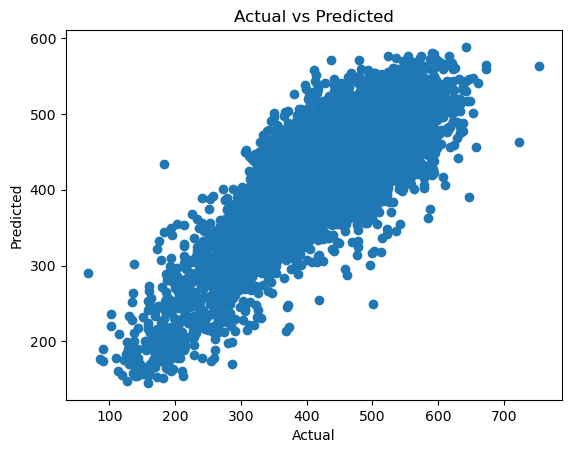

In [62]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [63]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=300, n_jobs=-1, learning_rate=0.1, max_depth=5)

model.fit(X_cls_train, Y_train)

Y_pred = model.predict(X_cls_test)

mse = mean_squared_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 1633.3546435056694, RMSE: 40.414782487422464, MAE: 31.085381554700014, R²: 0.6902315796511325


In [65]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
model = xgb.XGBRegressor(n_estimators=300, n_jobs=-1, learning_rate=0.05, max_depth=5)

model.fit(X_cls_train, Y_train)

Y_pred = model.predict(X_cls_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 1711.5361165973663, RMSE: 41.370715688725596, MAE: 31.892152524209667, R²: 0.6754043334578728


In [76]:
model = xgb.XGBRegressor(n_estimators=1000, n_jobs=-1, learning_rate=0.05, max_depth=5)

model.fit(X_cls_train, Y_train)

Y_pred = model.predict(X_cls_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 1548.0857540450131, RMSE: 39.345720911491924, MAE: 30.122274947960545, R²: 0.7064029661275184


In [77]:
%%time
model = xgb.XGBRegressor(n_estimators=1000, n_jobs=-1, learning_rate=0.05, max_depth=7)

model.fit(X_cls_train, Y_train)

Y_pred = model.predict(X_cls_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 1443.3658042785364, RMSE: 37.99165440302036, MAE: 28.930830969766642, R²: 0.7262632784896583
CPU times: user 11h 58min 12s, sys: 16min 19s, total: 12h 14min 32s
Wall time: 36min 57s


In [75]:
model = xgb.XGBRegressor(n_estimators=300, n_jobs=-1, learning_rate=0.05, max_depth=5)

model.fit(X_mean_train, Y_train)

Y_pred = model.predict(X_mean_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 1886.105678085012, RMSE: 43.429318185817884, MAE: 33.86131765917523, R²: 0.6422969262465651


In [22]:
Y

0        355.15
1        373.65
2        373.75
3        373.70
4        374.25
          ...  
98098    411.15
98099    458.15
98100    476.15
98101    450.15
98102    200.55
Name: MP, Length: 98103, dtype: float64

In [23]:
print(Y.describe())

count    98103.000000
mean       414.193341
std         72.469437
min         68.150000
25%        366.650000
50%        411.650000
75%        461.650000
max        790.150000
Name: MP, dtype: float64


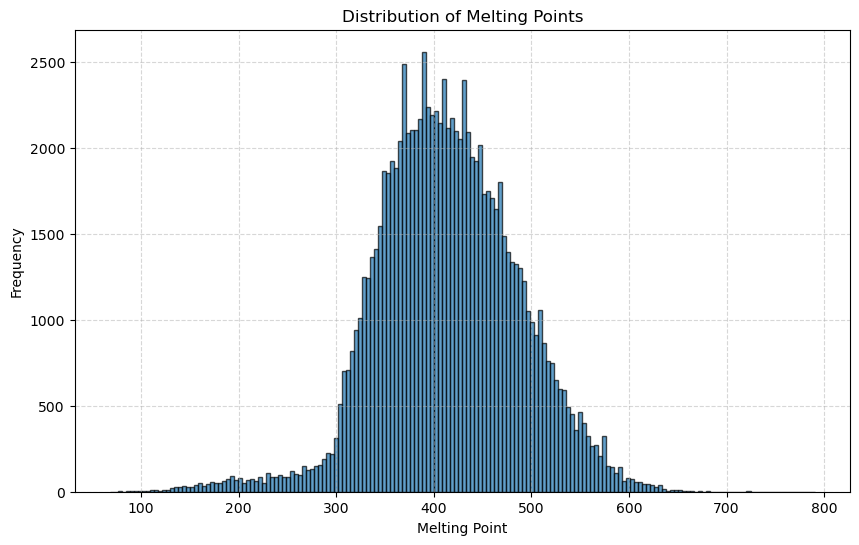

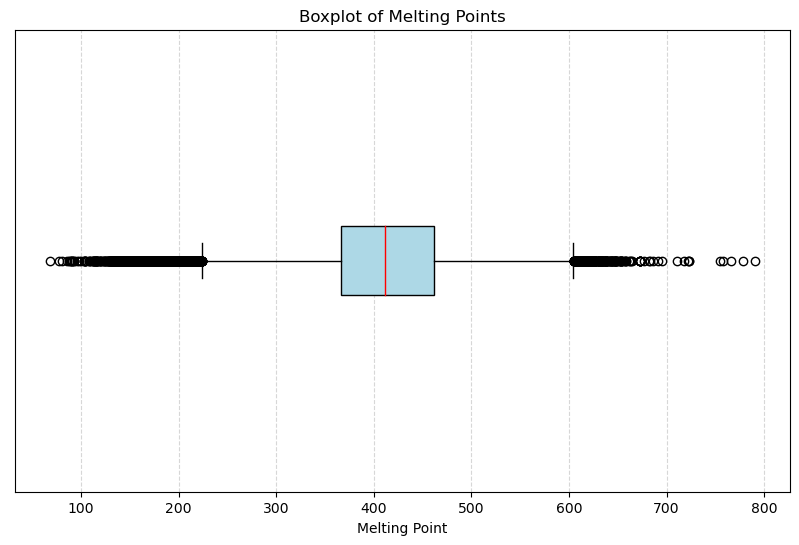

In [26]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(10,6))
plt.hist(Y, bins='auto', edgecolor='black', alpha=0.7)
plt.title('Distribution of Melting Points')
plt.xlabel('Melting Point')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Boxplot
plt.figure(figsize=(10,6))
plt.boxplot(Y.dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red'))
plt.title('Boxplot of Melting Points')
plt.xlabel('Melting Point')
plt.yticks([])  # Remove y-axis ticks as they don't mean anything for single boxplot
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [45]:
X_cls = X_cls.drop(columns=['3'])
X_cls

,2,4,5,6,7,8,9,10,11,12,...,592,593,594,595,596,597,598,599,600,601
0,-0.297464,-0.469301,0.613923,-0.091453,0.005680,-0.460268,-0.116542,0.091411,0.100729,0.588888,...,-0.262099,0.496665,-0.799587,-0.641183,0.040169,-0.305032,0.395968,-0.290227,0.386331,0.049372
1,-0.226974,-0.010051,0.641865,-0.501956,-0.292191,0.209096,-0.116981,-0.674928,-0.048467,-0.467837,...,-0.111003,-0.297623,-0.719133,-0.331790,0.209185,-0.250706,0.227153,-0.427968,0.355653,-0.053515
2,0.120824,0.343594,0.825011,0.335899,-0.083004,-0.132628,0.431794,-0.190523,-0.819905,-0.193580,...,-0.391887,-0.530868,-0.389782,-0.236005,0.426863,0.297661,0.091597,-0.492950,0.622310,0.281491
3,0.080562,-0.176777,0.535830,0.060789,-0.125329,0.234655,-0.292805,-0.585644,-0.230040,-0.650737,...,0.922502,-0.257208,-0.273421,0.045177,0.086653,-0.321508,0.087030,-0.761678,0.126587,0.501405
4,-0.160321,-0.266144,0.389632,0.340232,-0.193752,0.021855,0.044795,-0.141821,-0.631251,-0.527038,...,0.733791,0.547886,-0.701547,0.475795,0.187740,0.064449,-0.331698,-0.485444,0.220033,0.638294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98098,-0.448206,-0.455904,0.209826,0.142931,0.621407,0.025727,-0.444180,-0.044302,-0.039397,0.025070,...,0.061873,-0.521420,-0.351402,0.178205,-0.140142,-0.220700,0.184817,-0.396505,0.281736,0.106215
98099,-0.021670,-0.049890,0.725237,-0.578524,0.503573,0.324555,-0.110253,-0.169048,-0.006920,-0.416656,...,0.226097,-0.285199,-0.185580,-0.555275,-0.343661,-0.301649,-0.283752,0.037180,-0.465379,0.480829
98100,-0.176215,-0.392783,0.736764,-0.754783,0.161335,-0.243301,0.085528,-0.226288,0.073969,0.018142,...,0.101981,-0.100162,0.515925,-0.130599,-0.060739,0.543767,0.092447,-0.361396,-0.367399,0.333549
98101,-0.112313,-0.366849,0.490625,-0.543776,0.167046,-0.001483,0.016144,-0.162187,-0.042242,0.349511,...,0.337561,-0.298556,0.216073,-0.121964,0.199050,-0.118123,0.119501,-0.954171,-0.399389,0.264553


In [47]:
df = pd.concat([X_cls, Y], axis=1)
df

,2,4,5,6,7,8,9,10,11,12,...,593,594,595,596,597,598,599,600,601,MP
0,-0.297464,-0.469301,0.613923,-0.091453,0.005680,-0.460268,-0.116542,0.091411,0.100729,0.588888,...,0.496665,-0.799587,-0.641183,0.040169,-0.305032,0.395968,-0.290227,0.386331,0.049372,355.15
1,-0.226974,-0.010051,0.641865,-0.501956,-0.292191,0.209096,-0.116981,-0.674928,-0.048467,-0.467837,...,-0.297623,-0.719133,-0.331790,0.209185,-0.250706,0.227153,-0.427968,0.355653,-0.053515,373.65
2,0.120824,0.343594,0.825011,0.335899,-0.083004,-0.132628,0.431794,-0.190523,-0.819905,-0.193580,...,-0.530868,-0.389782,-0.236005,0.426863,0.297661,0.091597,-0.492950,0.622310,0.281491,373.75
3,0.080562,-0.176777,0.535830,0.060789,-0.125329,0.234655,-0.292805,-0.585644,-0.230040,-0.650737,...,-0.257208,-0.273421,0.045177,0.086653,-0.321508,0.087030,-0.761678,0.126587,0.501405,373.70
4,-0.160321,-0.266144,0.389632,0.340232,-0.193752,0.021855,0.044795,-0.141821,-0.631251,-0.527038,...,0.547886,-0.701547,0.475795,0.187740,0.064449,-0.331698,-0.485444,0.220033,0.638294,374.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98098,-0.448206,-0.455904,0.209826,0.142931,0.621407,0.025727,-0.444180,-0.044302,-0.039397,0.025070,...,-0.521420,-0.351402,0.178205,-0.140142,-0.220700,0.184817,-0.396505,0.281736,0.106215,411.15
98099,-0.021670,-0.049890,0.725237,-0.578524,0.503573,0.324555,-0.110253,-0.169048,-0.006920,-0.416656,...,-0.285199,-0.185580,-0.555275,-0.343661,-0.301649,-0.283752,0.037180,-0.465379,0.480829,458.15
98100,-0.176215,-0.392783,0.736764,-0.754783,0.161335,-0.243301,0.085528,-0.226288,0.073969,0.018142,...,-0.100162,0.515925,-0.130599,-0.060739,0.543767,0.092447,-0.361396,-0.367399,0.333549,476.15
98101,-0.112313,-0.366849,0.490625,-0.543776,0.167046,-0.001483,0.016144,-0.162187,-0.042242,0.349511,...,-0.298556,0.216073,-0.121964,0.199050,-0.118123,0.119501,-0.954171,-0.399389,0.264553,450.15


In [48]:
# Using IQR method
Q1 = df['MP'].quantile(0.25)
Q3 = df['MP'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['MP'] < (Q1 - 1.5 * IQR)) | (df['MP'] > (Q3 + 1.5 * IQR))]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 1694


In [89]:
Q1, Q3, IQR

(366.65, 461.65, 95.0)

In [49]:
# Calculate IQR
Q1 = df['MP'].quantile(0.25)
Q3 = df['MP'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a mask for non-outliers
mask = (df['MP'] >= lower_bound) & (df['MP'] <= upper_bound)

# Create new DataFrame without outliers
df_clean = df[mask].copy()

# Optional: Print info about removed rows
outliers_count = len(df) - len(df_clean)
print(f"Removed {outliers_count} outliers ({outliers_count/len(df)*100:.2f}% of data)")
print(f"Original shape: {df.shape}, Cleaned shape: {df_clean.shape}")

# If you want to modify the original DataFrame instead:
# df = df[mask].copy()

Removed 1694 outliers (1.73% of data)
Original shape: (98103, 600), Cleaned shape: (96409, 600)


In [53]:
df_clean = df_clean.reset_index(drop=True)

In [68]:
df_clean

,2,4,5,6,7,8,9,10,11,12,...,593,594,595,596,597,598,599,600,601,MP
0,-0.297464,-0.469301,0.613923,-0.091453,0.005680,-0.460268,-0.116542,0.091411,0.100729,0.588888,...,0.496665,-0.799587,-0.641183,0.040169,-0.305032,0.395968,-0.290227,0.386331,0.049372,355.15
1,-0.226974,-0.010051,0.641865,-0.501956,-0.292191,0.209096,-0.116981,-0.674928,-0.048467,-0.467837,...,-0.297623,-0.719133,-0.331790,0.209185,-0.250706,0.227153,-0.427968,0.355653,-0.053515,373.65
2,0.120824,0.343594,0.825011,0.335899,-0.083004,-0.132628,0.431794,-0.190523,-0.819905,-0.193580,...,-0.530868,-0.389782,-0.236005,0.426863,0.297661,0.091597,-0.492950,0.622310,0.281491,373.75
3,0.080562,-0.176777,0.535830,0.060789,-0.125329,0.234655,-0.292805,-0.585644,-0.230040,-0.650737,...,-0.257208,-0.273421,0.045177,0.086653,-0.321508,0.087030,-0.761678,0.126587,0.501405,373.70
4,-0.160321,-0.266144,0.389632,0.340232,-0.193752,0.021855,0.044795,-0.141821,-0.631251,-0.527038,...,0.547886,-0.701547,0.475795,0.187740,0.064449,-0.331698,-0.485444,0.220033,0.638294,374.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96404,-0.171751,-0.375602,0.598813,-0.322693,0.378518,-0.317191,-0.485390,-0.206954,-0.182052,0.056621,...,0.158315,-0.061668,-0.792260,-0.765911,-0.101481,-0.180282,0.099602,-0.367655,0.511330,414.15
96405,-0.448206,-0.455904,0.209826,0.142931,0.621407,0.025727,-0.444180,-0.044302,-0.039397,0.025070,...,-0.521420,-0.351402,0.178205,-0.140142,-0.220700,0.184817,-0.396505,0.281736,0.106215,411.15
96406,-0.021670,-0.049890,0.725237,-0.578524,0.503573,0.324555,-0.110253,-0.169048,-0.006920,-0.416656,...,-0.285199,-0.185580,-0.555275,-0.343661,-0.301649,-0.283752,0.037180,-0.465379,0.480829,458.15
96407,-0.176215,-0.392783,0.736764,-0.754783,0.161335,-0.243301,0.085528,-0.226288,0.073969,0.018142,...,-0.100162,0.515925,-0.130599,-0.060739,0.543767,0.092447,-0.361396,-0.367399,0.333549,476.15


In [69]:
df_clean.to_csv('df_clean.csv', index=False)

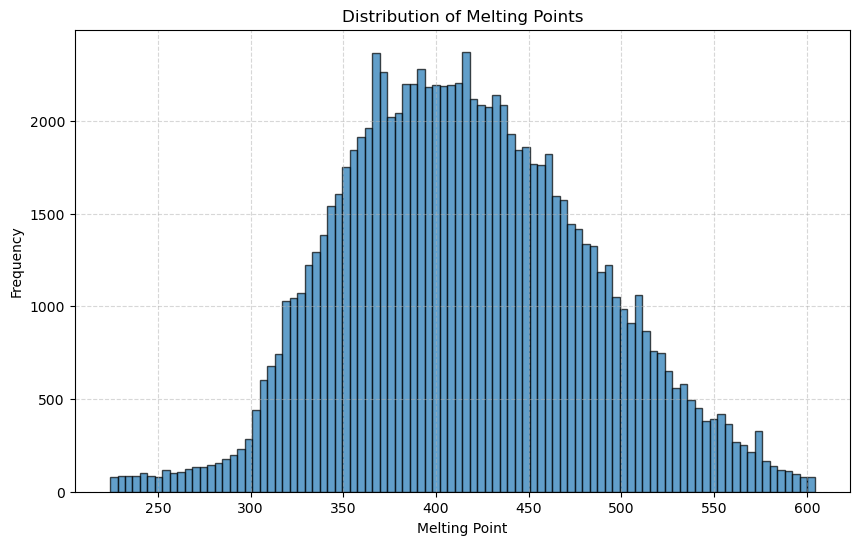

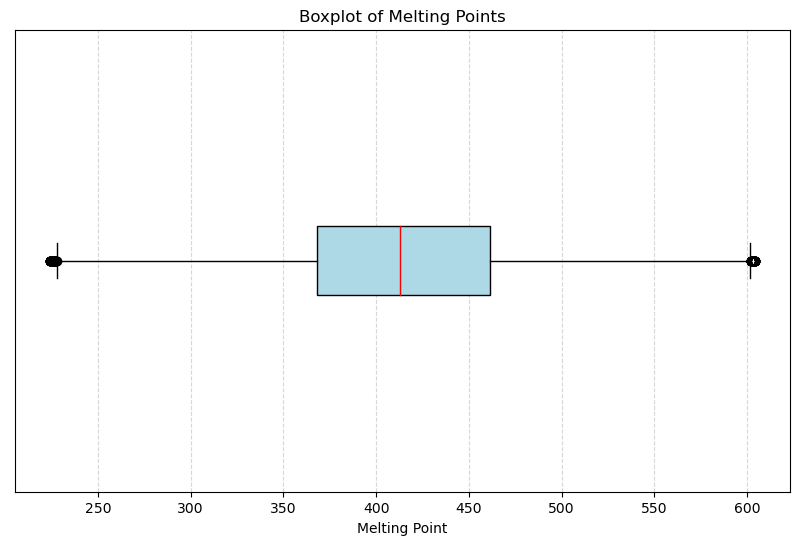

In [87]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(10,6))
plt.hist(df_clean['MP'], bins='auto', edgecolor='black', alpha=0.7)
plt.title('Distribution of Melting Points')
plt.xlabel('Melting Point')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Boxplot
plt.figure(figsize=(10,6))
plt.boxplot(df_clean['MP'].dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red'))
plt.title('Boxplot of Melting Points')
plt.xlabel('Melting Point')
plt.yticks([])  # Remove y-axis ticks as they don't mean anything for single boxplot
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [60]:
df_clean.iloc[:, -1]

0        355.15
1        373.65
2        373.75
3        373.70
4        374.25
          ...  
96404    414.15
96405    411.15
96406    458.15
96407    476.15
96408    450.15
Name: MP, Length: 96409, dtype: float64

In [61]:
from sklearn.model_selection import train_test_split
X_cls_train, X_cls_test, Y_train, Y_test = train_test_split(df_clean.iloc[:, :-1], df_clean.iloc[:, -1], test_size=0.2, random_state=42)

In [76]:
%%time
model = xgb.XGBRegressor(n_estimators=1000, n_jobs=-1, learning_rate=0.05, max_depth=7)

model.fit(X_cls_train, Y_train)

Y_pred = model.predict(X_cls_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R²: {r2}")

MSE: 1377.6584293662343, RMSE: 37.116821380153695, MAE: 28.453733485238555, R²: 0.6834748364291741
CPU times: user 16h 4min 11s, sys: 52min 50s, total: 16h 57min 1s
Wall time: 52min 35s


In [77]:
df_mp = pd.read_csv('smiles_mp.csv')
df_mp

,MP,smiles
0,355.15,O=[N+]([O-])c1c(O)cccc1O
1,373.65,Cc1c([N+](=O)[O-])cc([N+](=O)[O-])c(N(C)[N+](=...
2,373.75,O=c1ccc([N+](=O)[O-])cn1Cc1ccccc1
3,373.70,N#CC(Cc1ccccc1)(Cc1ccco1)c1ccc([N+](=O)[O-])cc1
4,374.25,CCOC(=O)c1cc2ccccc2cc1-c1ccc([N+](=O)[O-])cc1
...,...,...
98098,411.15,CCCCNC(=O)C(c1cc(OC)cc(OC)c1)N(Cc1ccccc1)C(=O)...
98099,458.15,CCCCNC(=O)C(c1cc2ccccc2c2ccccc12)N(Cc1ccco1)C(...
98100,476.15,CC(C)(C)NC(=O)C(c1ccccc1)N(Cc1ccco1)C(=O)CNC(=...
98101,450.15,COc1ccc(C(C(=O)NCc2ccccc2)N(Cc2ccc(C)o2)C(=O)C...


In [78]:
df_mp = df_mp.rename(columns = {'smiles' : 'SMILES', 'MP' : 'TARGET'})
df_mp

,TARGET,SMILES
0,355.15,O=[N+]([O-])c1c(O)cccc1O
1,373.65,Cc1c([N+](=O)[O-])cc([N+](=O)[O-])c(N(C)[N+](=...
2,373.75,O=c1ccc([N+](=O)[O-])cn1Cc1ccccc1
3,373.70,N#CC(Cc1ccccc1)(Cc1ccco1)c1ccc([N+](=O)[O-])cc1
4,374.25,CCOC(=O)c1cc2ccccc2cc1-c1ccc([N+](=O)[O-])cc1
...,...,...
98098,411.15,CCCCNC(=O)C(c1cc(OC)cc(OC)c1)N(Cc1ccccc1)C(=O)...
98099,458.15,CCCCNC(=O)C(c1cc2ccccc2c2ccccc12)N(Cc1ccco1)C(...
98100,476.15,CC(C)(C)NC(=O)C(c1ccccc1)N(Cc1ccco1)C(=O)CNC(=...
98101,450.15,COc1ccc(C(C(=O)NCc2ccccc2)N(Cc2ccc(C)o2)C(=O)C...


In [79]:
df_mp.to_csv('df-for-unimol.csv', index=False)

In [80]:
from sklearn.model_selection import train_test_split

# X is your feature matrix, y is your target vector
X_train, X_test = train_test_split(df_mp, test_size=0.2, random_state=42)

In [81]:
X_train

,TARGET,SMILES
30378,461.15,O=C(Cn1cc([N+](=O)[O-])c2cccnc21)NCCO
38670,433.65,O=[N+]([O-])Nc1nc(-c2ccccc2[N+](=O)[O-])n[nH]1
58519,378.65,CC(=O)c1onc(C#N)c1-c1ccc([N+](=O)[O-])cc1
50596,400.15,CCN(CC)CCn1nc2c([N+](=O)[O-])ccc3c2c1-c1ccccc1-3
65392,469.15,O=C(c1ccc([N+](=O)[O-])c(O)c1)C1OC1c1ccc([N+](...
...,...,...
6265,355.65,CC(NC(=O)OC(C)(C)C)C(=O)Oc1ccc([N+](=O)[O-])cc1
54886,388.65,CO[C@@H]1O[C@@H](C)C=C([N+](=O)[O-])[C@@H]1O
76820,344.15,C[C@@H]1CN(Cc2ccc([N+](=O)[O-])cc2)C[C@](F)(Cl)C1
860,372.15,O=[N+]([O-])c1cn([C@H](CO)[C@@H](O)[C@H](O)[C@...


In [82]:
X_test

,TARGET,SMILES
68060,438.15,COc1nc(N)nc(CN=Nc2ccc([N+](=O)[O-])cc2)c1[N+](...
63858,490.15,CCc1nc(C)nc(-c2ccccc2)c1-c1ccc([N+](=O)[O-])cc1O
75216,366.15,Cc1ccc(NC(=O)O/N=C\c2ccccc2[N+](=O)[O-])cc1
61216,548.15,O=[N+]([O-])c1cc(/C=N/Nc2ccccn2)ccc1Cl
10308,340.65,O=[N+]([O-])c1ccc(Cc2cnc3ccccc3n2)c([N+](=O)[O...
...,...,...
61740,532.15,CCOC(=O)c1[nH]c(C(=O)O)c(Cl)c1-c1ccccc1[N+](=O...
33232,451.40,CN(C)c1ccc2ccc3ccc([N+](=O)[O-])c4ccc1c2c34
30969,459.15,COc1cc([N+](=O)[O-])cc2c(=O)c(N)coc12
59656,375.15,O=[N+]([O-])c1ccc(CCNc2ccc(OC(F)(F)F)cc2)nc1


In [85]:
X_train.to_csv('train_data.csv', index=False)

In [84]:
X_test.to_csv('test_data.csv', index=False)